# 🎵 Genre Investment Analysis for Record Labels
## A Data-Driven Approach to Music Genre Portfolio Strategy

**Course:** ACC102 Mini Assignment — Track 4 (Interactive Tool)

**Dataset:** Spotify Global Streaming Data 2024

**Target User:** A&R (Artist & Repertoire) decision-makers at a record label

---

### Core Business Question
> Among all music genres on Spotify's global platform, which genres offer the best commercial return — considering streaming volume, listener engagement, artist market structure, and paid subscription revenue?

### Analysis Structure
1. Setup & data loading
2. Full landscape: all 10 genres
3. Deep dive: focus genres
4. Artist-level analysis (market concentration & star power)
5. Album & engagement quality analysis
6. Regional analysis + world map
7. Revenue estimation & momentum
8. Investment recommendation

In [1]:
# ══════════════════════════════════════════════════════
# 0. SETUP & CONFIGURATION
# Modify FOCUS_GENRES to analyse different genres
# ══════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
from matplotlib.gridspec import GridSpec
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── CONFIGURATION ─────────────────────────────────────
DATA_FILE        = 'Cleaned_Spotify_2024_Global_Streaming_Data.csv'
FOCUS_GENRES     = ['Pop', 'R&B', 'Rock', 'Jazz']   # ← change here to analyse different genres
TOP_N_ARTISTS    = 8                                  # artists to show in artist charts
PER_STREAM_RATE  = {'Premium': 0.005, 'Free': 0.002} # USD per stream

# Column aliases
STREAM_COL        = 'Total Streams (Millions)'
LISTENER_COL      = 'Monthly Listeners (Millions)'
DURATION_COL      = 'Avg Stream Duration (Min)'
SKIP_COL          = 'Skip Rate (%)'
HOURS_COL         = 'Total Hours Streamed (Millions)'
PLATFORM_COL      = 'Platform Type'
GENRE_COL         = 'Genre'
COUNTRY_COL       = 'Country'
ARTIST_COL        = 'Artist'
ALBUM_COL         = 'Album'
RECENT_STREAM_COL = 'Streams Last 30 Days (Millions)'
RELEASE_COL       = 'Release Year'

# ── PREMIUM COLOUR PALETTE ────────────────────────────
# Muted, editorial-quality palette — inspired by music industry branding
GENRE_COLORS = {
    'Pop':       '#C0392B',   # deep crimson
    'R&B':       '#6C3483',   # deep violet
    'Rock':      '#1A5276',   # deep navy
    'Jazz':      '#B7950B',   # warm gold
    'Hip Hop':   '#1E8449',   # forest green
    'K-pop':     '#A93226',   # burgundy
    'EDM':       '#117A65',   # deep teal
    'Reggaeton': '#935116',   # burnt sienna
    'Indie':     '#4A235A',   # plum
    'Classical': '#424949',   # slate
}

# Chart aesthetics
plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 160,
    'font.family': 'serif',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.titleweight': 'bold',
})

REGION_MAP = {
    'United States': 'North America', 'Canada': 'North America',
    'Mexico': 'Latin America', 'Brazil': 'Latin America', 'Argentina': 'Latin America',
    'United Kingdom': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Spain': 'Europe', 'Italy': 'Europe', 'Netherlands': 'Europe',
    'Sweden': 'Europe', 'Russia': 'Europe', 'Turkey': 'Europe',
    'India': 'Asia-Pacific', 'Japan': 'Asia-Pacific',
    'South Korea': 'Asia-Pacific', 'Indonesia': 'Asia-Pacific', 'Australia': 'Asia-Pacific',
    'South Africa': 'Africa'
}

print("✓ Setup complete.")
print(f"  Focus genres  : {FOCUS_GENRES}")
print(f"  Colour palette: custom editorial")

✓ Setup complete.
  Focus genres  : ['Pop', 'R&B', 'Rock', 'Jazz']
  Colour palette: custom editorial


## 1. Data Loading & Exploration

**Source:** [Kaggle — Spotify Global Streaming Data 2024](https://www.kaggle.com/datasets/atharvasoundankar/spotify-global-streaming-data-2024)
**Access date:** April 2026 · **Size:** 500 rows × 12 columns · 20 countries · 10 genres

In [2]:
df = pd.read_csv(DATA_FILE)
df['Region'] = df[COUNTRY_COL].map(REGION_MAP)

# Derived metrics useful for business analysis
df['Engagement_Ratio']   = (df[HOURS_COL] / df[STREAM_COL]).round(4)   # hours per stream
df['Momentum_Pct']       = (df[RECENT_STREAM_COL] / df[STREAM_COL] * 100).round(2)  # recent vs total
df['Revenue_Est']        = df.apply(
    lambda r: r[STREAM_COL] * PER_STREAM_RATE.get(r[PLATFORM_COL], 0.003), axis=1
).round(2)

print(f"Rows: {len(df)}  |  Columns: {len(df.columns)}")
print(f"Genres   : {sorted(df[GENRE_COL].unique())}")
print(f"Countries: {sorted(df[COUNTRY_COL].unique())}")
print(f"Artists  : {df[ARTIST_COL].nunique()} unique")
df.describe().round(2)

Rows: 500  |  Columns: 16
Genres   : ['Classical', 'EDM', 'Hip Hop', 'Indie', 'Jazz', 'K-pop', 'Pop', 'R&B', 'Reggaeton', 'Rock']
Countries: ['Argentina', 'Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Indonesia', 'Italy', 'Japan', 'Mexico', 'Netherlands', 'Russia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Turkey', 'United Kingdom', 'United States']
Artists  : 15 unique


,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Streams Last 30 Days (Millions),Skip Rate (%),Engagement_Ratio,Momentum_Pct,Revenue_Est
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,2020.63,51.04,2581.15,8954.37,3.52,99.05,20.37,3.48,8.04,9.07
std,1.72,28.24,1416.06,5167.65,0.57,57.53,10.60,0.59,19.91,6.71
min,2018.00,1.01,53.56,184.30,2.51,2.85,1.16,2.50,0.07,0.11
25%,2019.00,27.67,1337.34,4322.10,3.03,48.06,11.15,2.95,1.96,3.72
50%,2020.00,50.82,2697.35,9053.67,3.54,101.46,20.82,3.45,3.82,7.16
75%,2022.00,75.10,3798.20,12690.18,4.00,148.41,28.76,3.97,7.21,13.85
max,2023.00,99.80,4985.54,21874.92,4.49,200.00,39.97,4.49,329.91,24.93


## 2. Full Landscape: All 10 Genres

Before narrowing focus, we map the entire market to avoid blind spots.

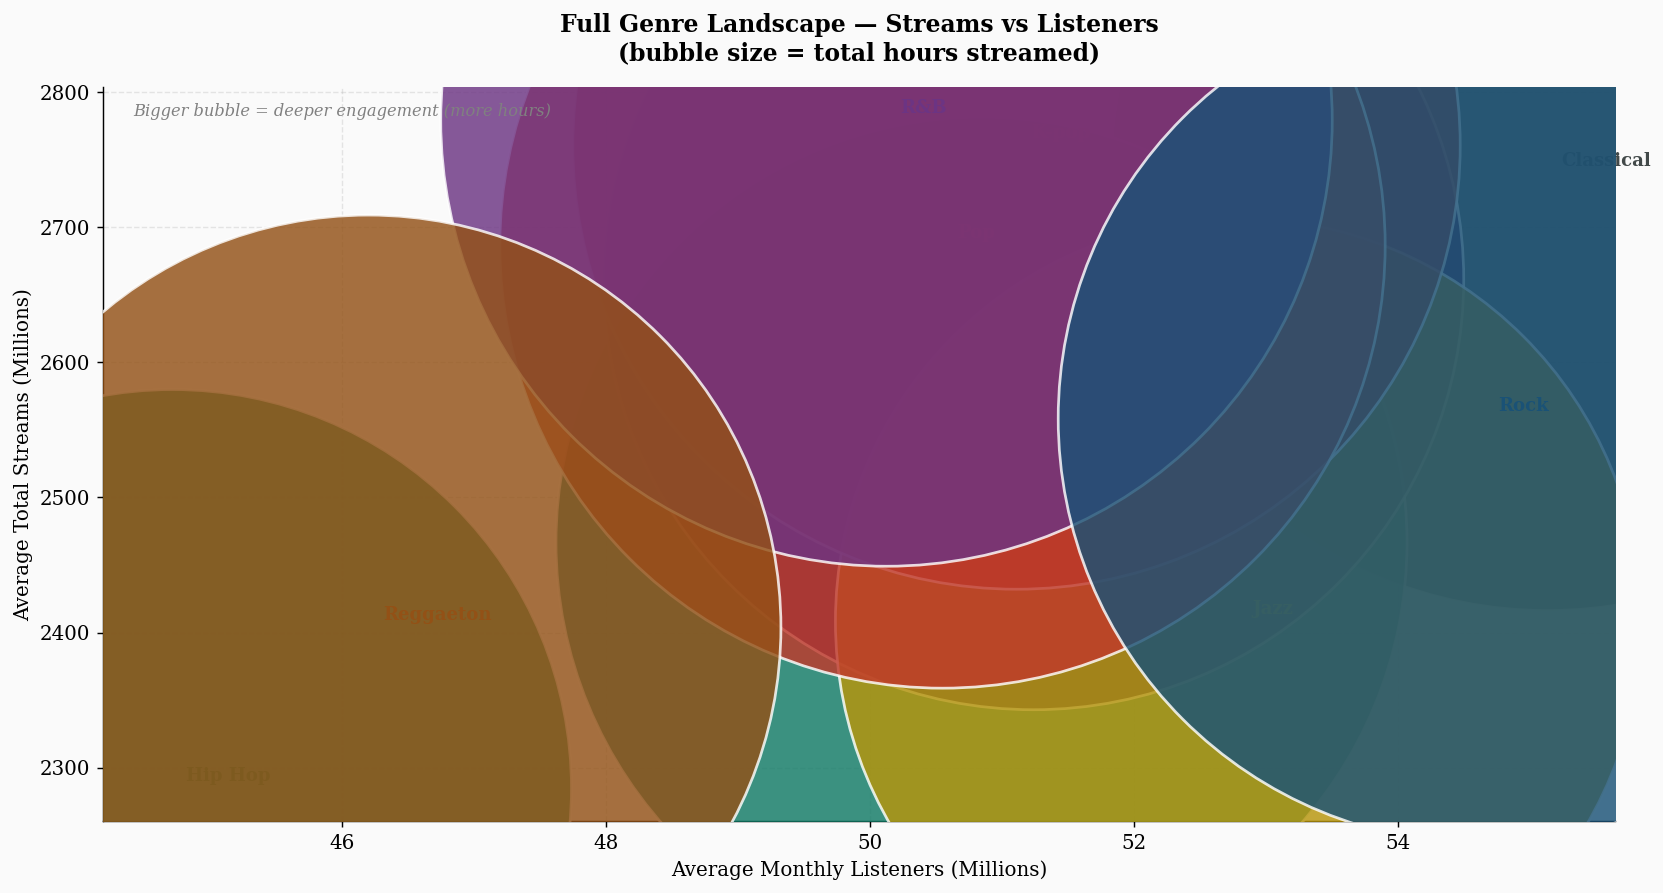

In [3]:
# ── Figure 1: Landscape Bubble Chart ─────────────────
# X = avg listeners, Y = avg streams, bubble = avg hours, colour = genre
all_m = df.groupby(GENRE_COL).agg(
    Avg_Streams   = (STREAM_COL, 'mean'),
    Avg_Listeners = (LISTENER_COL, 'mean'),
    Avg_Hours     = (HOURS_COL, 'mean'),
    Avg_Skip      = (SKIP_COL, 'mean'),
    Count         = (STREAM_COL, 'count'),
).round(2)

fig, ax = plt.subplots(figsize=(13, 7))
for genre, row in all_m.iterrows():
    c = GENRE_COLORS.get(genre, '#888')
    ax.scatter(row['Avg_Listeners'], row['Avg_Streams'],
               s=row['Avg_Hours'] * 25, color=c, alpha=0.82,
               edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(genre, (row['Avg_Listeners'], row['Avg_Streams']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold', color=c)

ax.set_xlabel('Average Monthly Listeners (Millions)')
ax.set_ylabel('Average Total Streams (Millions)')
ax.set_title('Full Genre Landscape — Streams vs Listeners\n(bubble size = total hours streamed)', pad=15)
ax.annotate('Bigger bubble = deeper engagement (more hours)', xy=(0.02, 0.96),
            xycoords='axes fraction', fontsize=9, color='gray', style='italic')
plt.tight_layout()
plt.savefig('figure_1_landscape_bubble.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

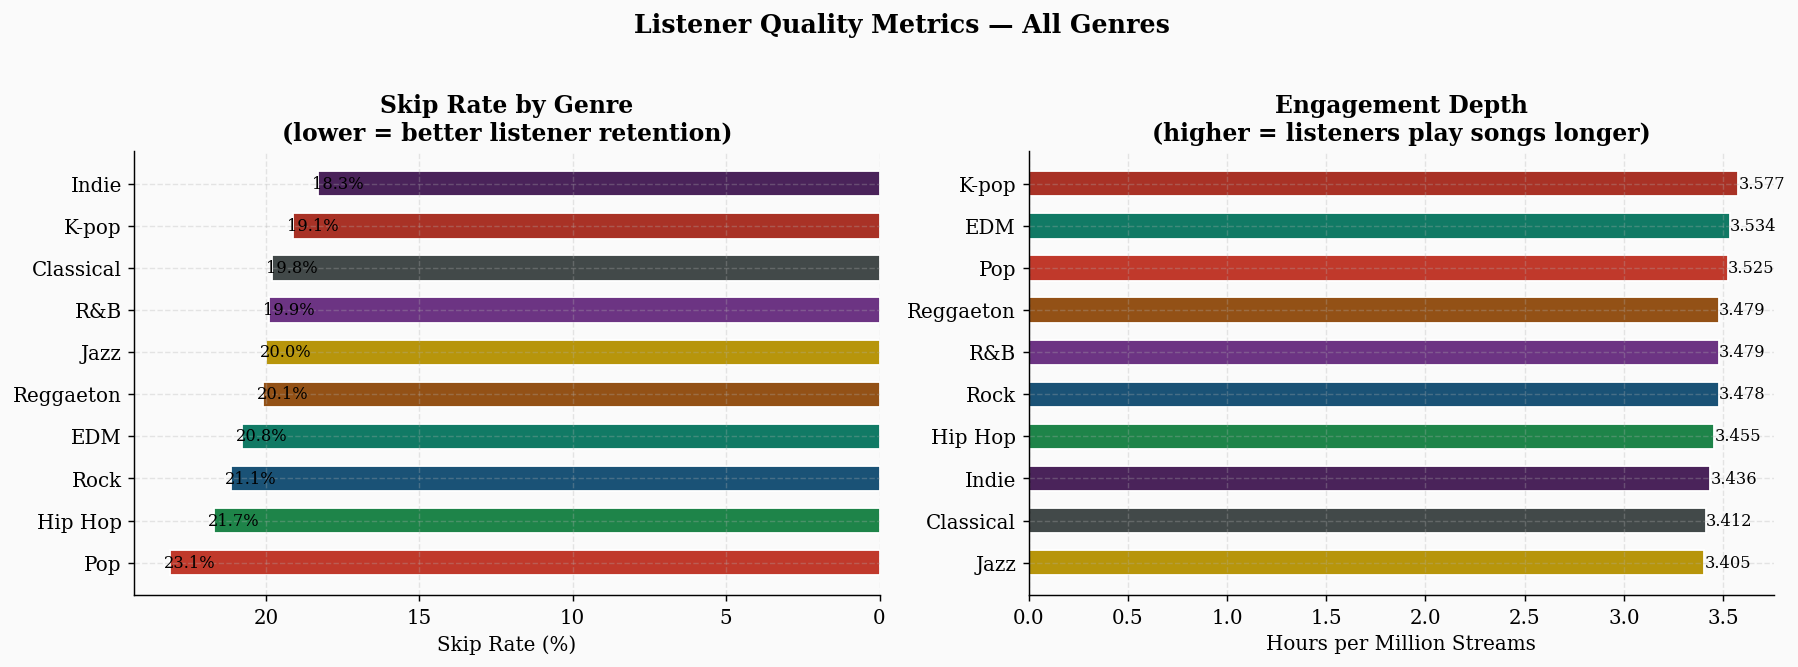

In [5]:
# ── Figure 2: Diverging Bar — Skip Rate vs Engagement ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Skip rate (lower is better — invert axis)
skip_data = all_m['Avg_Skip'].sort_values(ascending=False)
colors = [GENRE_COLORS.get(g, '#888') for g in skip_data.index]
bars = axes[0].barh(skip_data.index, skip_data.values, color=colors, edgecolor='white', height=0.6)
axes[0].set_xlabel('Skip Rate (%)')
axes[0].set_title('Skip Rate by Genre\n(lower = better listener retention)')
for bar, val in zip(bars, skip_data.values):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].invert_xaxis()

# Right: Engagement ratio (hours per million streams)
eng = df.groupby(GENRE_COL)['Engagement_Ratio'].mean().sort_values(ascending=True)
colors2 = [GENRE_COLORS.get(g, '#888') for g in eng.index]
bars2 = axes[1].barh(eng.index, eng.values, color=colors2, edgecolor='white', height=0.6)
axes[1].set_xlabel('Hours per Million Streams')
axes[1].set_title('Engagement Depth\n(higher = listeners play songs longer)')
for bar, val in zip(bars2, eng.values):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Listener Quality Metrics — All Genres', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_2_listener_quality.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

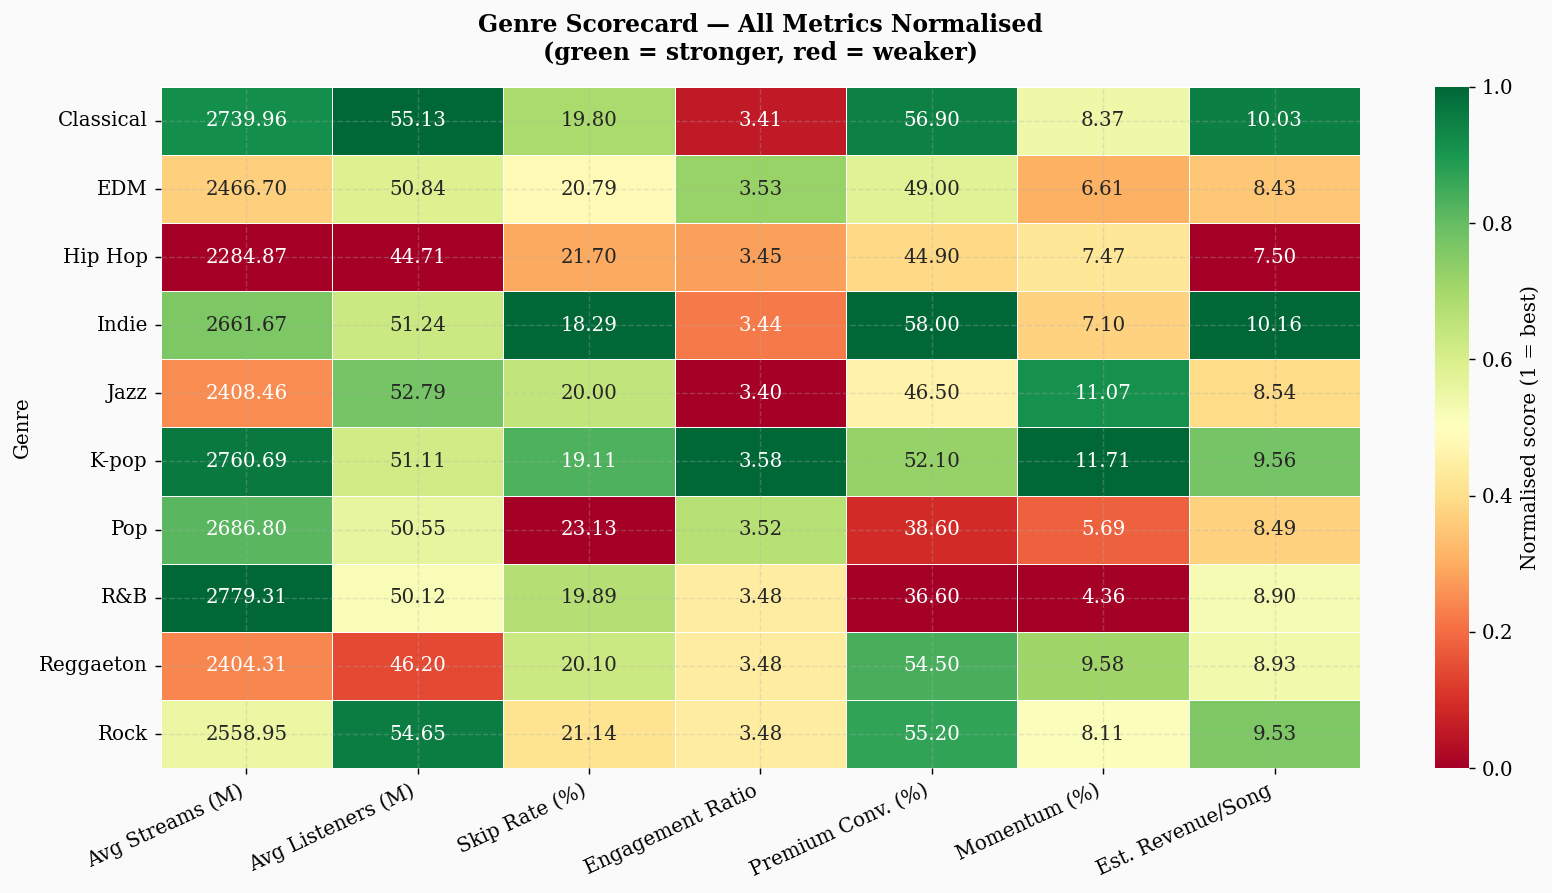

In [7]:
# ── Figure 3: Premium Conversion + Momentum Heatmap ──
plat_all = df.groupby([GENRE_COL, PLATFORM_COL]).size().unstack(fill_value=0)
plat_all['Total']       = plat_all.sum(axis=1)
plat_all['Premium_Pct'] = (plat_all['Premium'] / plat_all['Total'] * 100).round(1)

momentum = df.groupby(GENRE_COL)['Momentum_Pct'].mean().round(2)
revenue  = df.groupby(GENRE_COL)['Revenue_Est'].mean().round(2)

summary_all = pd.DataFrame({
    'Avg Streams (M)'    : all_m['Avg_Streams'],
    'Avg Listeners (M)'  : all_m['Avg_Listeners'],
    'Skip Rate (%)'      : all_m['Avg_Skip'],
    'Engagement Ratio'   : df.groupby(GENRE_COL)['Engagement_Ratio'].mean(),
    'Premium Conv. (%)'  : plat_all['Premium_Pct'],
    'Momentum (%)'       : momentum,
    'Est. Revenue/Song'  : revenue,
}).round(2)

# Normalise 0-1 for heatmap (flip skip rate so low = good = dark)
norm = summary_all.copy()
for col in norm.columns:
    rng = norm[col].max() - norm[col].min()
    if rng > 0:
        if col == 'Skip Rate (%)':
            norm[col] = 1 - (norm[col] - norm[col].min()) / rng
        else:
            norm[col] = (norm[col] - norm[col].min()) / rng

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(norm, annot=summary_all, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Normalised score (1 = best)'})
ax.set_title('Genre Scorecard — All Metrics Normalised\n(green = stronger, red = weaker)', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.savefig('figure_3_scorecard_heatmap.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

## 3. Deep Dive: Focus Genres

> **Reusability note:** Change `FOCUS_GENRES` in Cell 2 and re-run all cells to analyse any combination of genres.

In [8]:
df_focus = df[df[GENRE_COL].isin(FOCUS_GENRES)].copy()
print(f"Focus genres  : {FOCUS_GENRES}")
print(f"Observations  : {len(df_focus)} ({len(df_focus)/len(df)*100:.1f}% of total)")
print(df_focus[GENRE_COL].value_counts())

Focus genres  : ['Pop', 'R&B', 'Rock', 'Jazz']
Observations  : 186 (37.2% of total)
Genre
Rock    58
Pop     44
Jazz    43
R&B     41
Name: count, dtype: int64


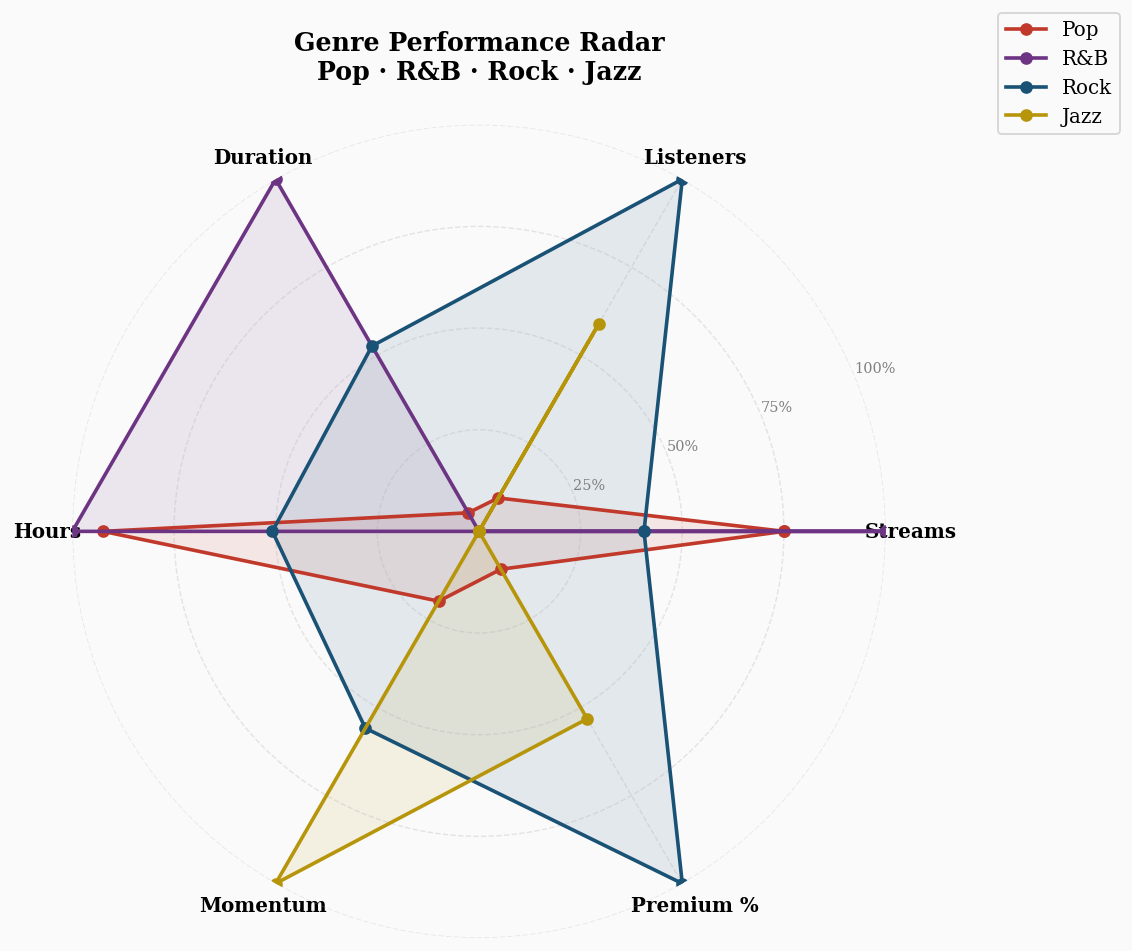

In [9]:
# ── Figure 4: Radar / Spider Chart ───────────────────
from matplotlib.patches import FancyArrowPatch

focus_m = df_focus.groupby(GENRE_COL).agg(
    Streams   = (STREAM_COL, 'mean'),
    Listeners = (LISTENER_COL, 'mean'),
    Duration  = (DURATION_COL, 'mean'),
    Hours     = (HOURS_COL, 'mean'),
    Momentum  = ('Momentum_Pct', 'mean'),
).round(2).reindex(FOCUS_GENRES)

# Add premium conversion
pf = df_focus.groupby([GENRE_COL, PLATFORM_COL]).size().unstack(fill_value=0).reindex(FOCUS_GENRES)
pf['Premium_Pct'] = (pf['Premium'] / pf.sum(axis=1) * 100).round(1)
focus_m['Premium'] = pf['Premium_Pct']

# Normalise 0-1
norm_r = focus_m.copy()
for col in norm_r.columns:
    rng = norm_r[col].max() - norm_r[col].min()
    if rng > 0:
        norm_r[col] = (norm_r[col] - norm_r[col].min()) / rng

labels = ['Streams', 'Listeners', 'Duration', 'Hours', 'Momentum', 'Premium %']
N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor('#FAFAFA')

for genre in FOCUS_GENRES:
    vals = norm_r.loc[genre].tolist() + [norm_r.loc[genre].tolist()[0]]
    c = GENRE_COLORS[genre]
    ax.plot(angles, vals, 'o-', linewidth=2, color=c, label=genre)
    ax.fill(angles, vals, alpha=0.10, color=c)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
ax.spines['polar'].set_visible(False)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=11)
ax.set_title(f'Genre Performance Radar\n{" · ".join(FOCUS_GENRES)}',
             fontsize=14, fontweight='bold', pad=25)
plt.tight_layout()
plt.savefig('figure_4_radar.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

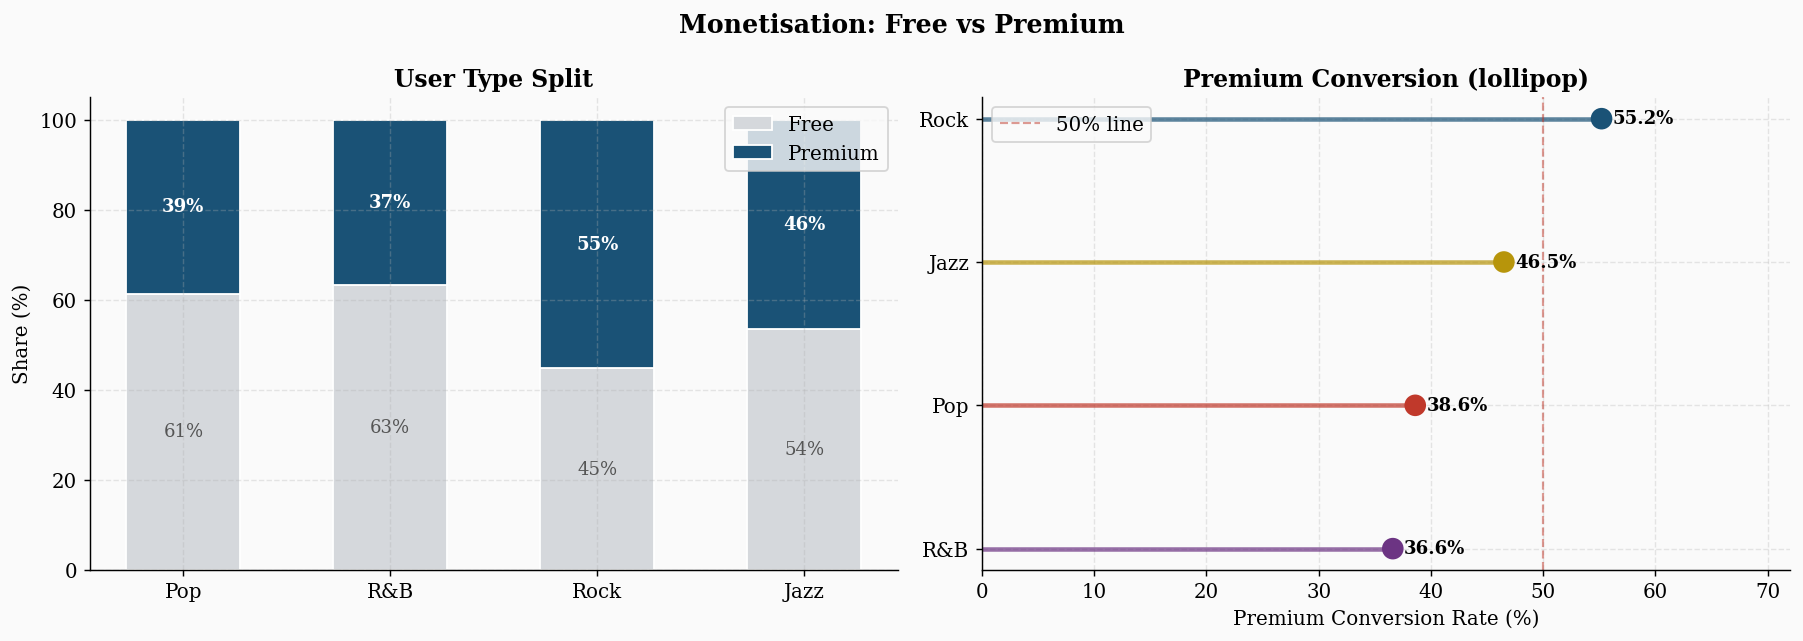

In [10]:
# ── Figure 5: Monetisation — Stacked + Lollipop ──────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monetisation: Free vs Premium', fontsize=14, fontweight='bold')

pf2 = df_focus.groupby([GENRE_COL, PLATFORM_COL]).size().unstack(fill_value=0).reindex(FOCUS_GENRES)
pf2['Total'] = pf2.sum(axis=1)
pf2['Prem%'] = (pf2['Premium'] / pf2['Total'] * 100).round(1)
pf2['Free%'] = (pf2['Free']    / pf2['Total'] * 100).round(1)

x = np.arange(len(FOCUS_GENRES))
ax1.bar(x, pf2['Free%'],  0.55, label='Free',    color='#D5D8DC', edgecolor='white')
ax1.bar(x, pf2['Prem%'],  0.55, bottom=pf2['Free%'], label='Premium', color='#1A5276', edgecolor='white')
for i, (fp, pp) in enumerate(zip(pf2['Free%'], pf2['Prem%'])):
    ax1.text(i, fp/2,       f'{fp:.0f}%', ha='center', va='center', color='#555', fontsize=10)
    ax1.text(i, fp + pp/2,  f'{pp:.0f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(FOCUS_GENRES)
ax1.set_ylabel('Share (%)'); ax1.set_title('User Type Split'); ax1.legend()

# Lollipop chart for premium conversion
sorted_pf = pf2['Prem%'].sort_values()
ypos = np.arange(len(sorted_pf))
ax2.hlines(ypos, 0, sorted_pf.values, colors=[GENRE_COLORS[g] for g in sorted_pf.index],
           linewidth=2.5, alpha=0.7)
ax2.scatter(sorted_pf.values, ypos,
            color=[GENRE_COLORS[g] for g in sorted_pf.index], s=120, zorder=5)
ax2.axvline(50, color='#C0392B', linestyle='--', alpha=0.5, linewidth=1.2, label='50% line')
for val, y in zip(sorted_pf.values, ypos):
    ax2.text(val + 1, y, f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
ax2.set_yticks(ypos); ax2.set_yticklabels(sorted_pf.index)
ax2.set_xlabel('Premium Conversion Rate (%)'); ax2.set_title('Premium Conversion (lollipop)')
ax2.set_xlim(0, 72); ax2.legend()

plt.tight_layout()
plt.savefig('figure_5_monetisation.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

## 4. Artist-Level Analysis

For a record label, artist-level data answers critical signing decisions:
- **Market concentration:** Is one genre dominated by a few superstars, leaving little room for new artists?
- **Star power vs long tail:** Which genres reward investment in a single blockbuster artist vs a broad roster?
- **Top performer identification:** Who are the standout artists driving each genre's numbers?

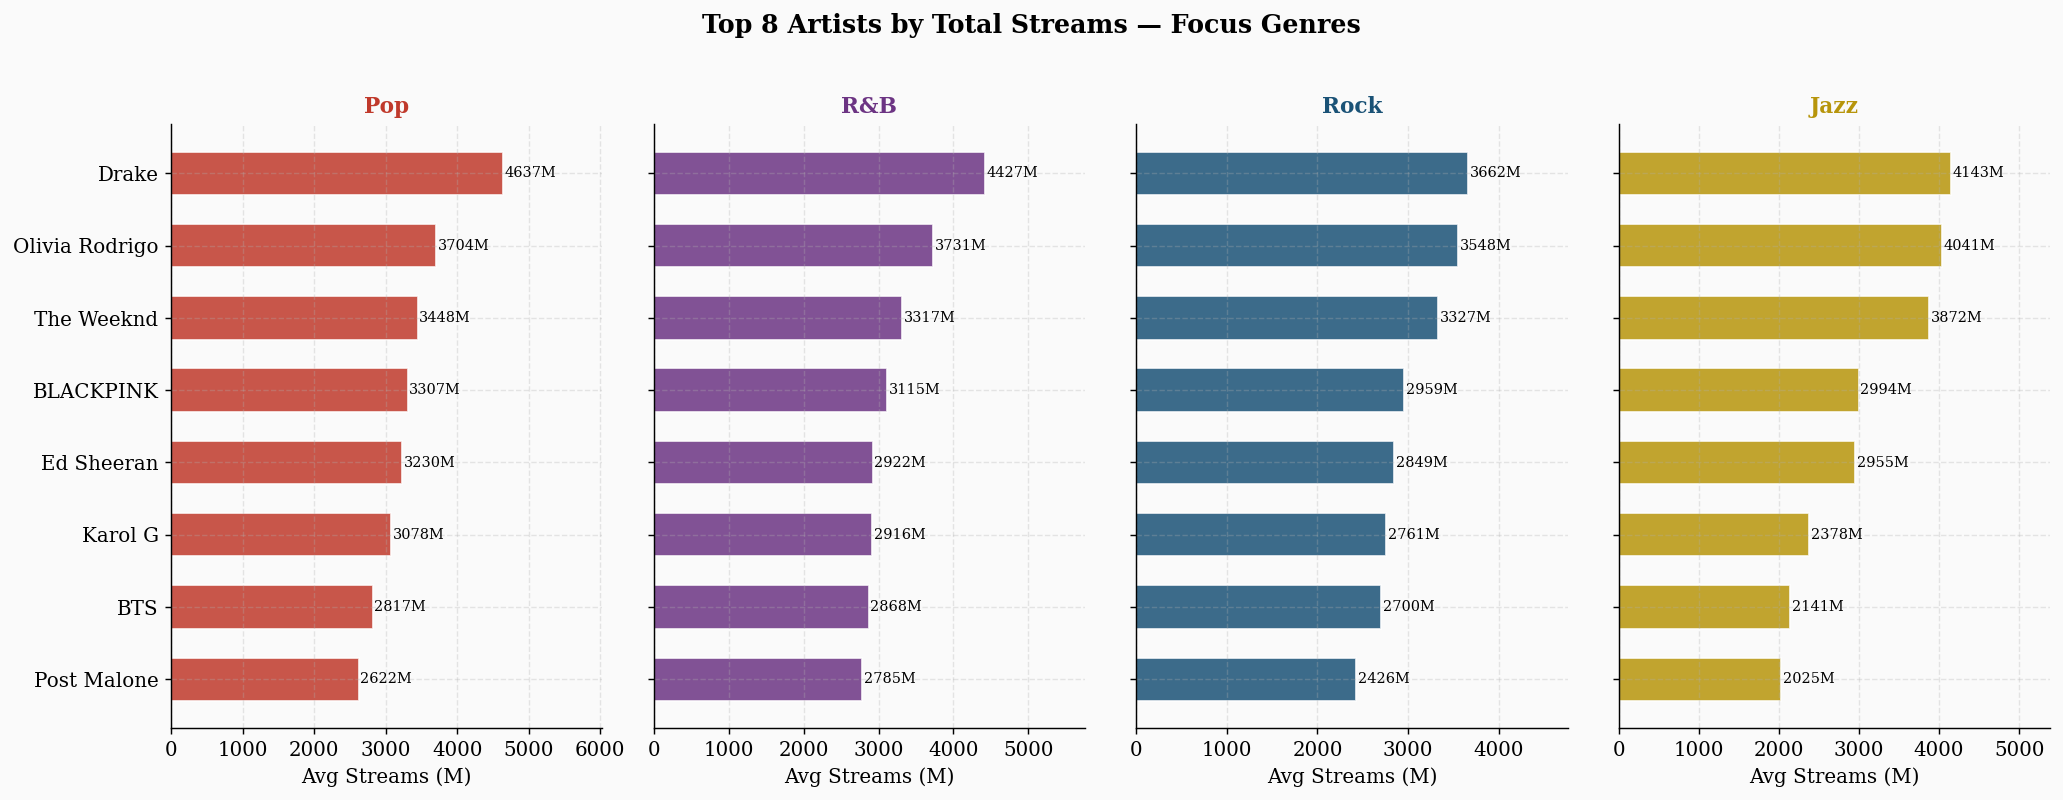

In [11]:
# ── Figure 6: Top Artists per Genre (horizontal facets) ─
fig, axes = plt.subplots(1, len(FOCUS_GENRES), figsize=(16, 6))
fig.suptitle(f'Top {TOP_N_ARTISTS} Artists by Total Streams — Focus Genres',
             fontsize=14, fontweight='bold', y=1.02)

for idx, genre in enumerate(FOCUS_GENRES):
    ax = axes[idx]
    subset = df_focus[df_focus[GENRE_COL] == genre]
    top = subset.groupby(ARTIST_COL)[STREAM_COL].mean().nlargest(TOP_N_ARTISTS).sort_values()
    c = GENRE_COLORS[genre]
    
    bars = ax.barh(top.index, top.values, color=c, alpha=0.85, edgecolor='white', height=0.6)
    for bar, val in zip(bars, top.values):
        ax.text(val + 20, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}M', va='center', fontsize=8)
    
    ax.set_title(genre, fontweight='bold', color=c, fontsize=12)
    ax.set_xlabel('Avg Streams (M)')
    if idx > 0: ax.set_yticklabels([])
    ax.set_xlim(0, top.max() * 1.3)

plt.tight_layout()
plt.savefig('figure_6_top_artists.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

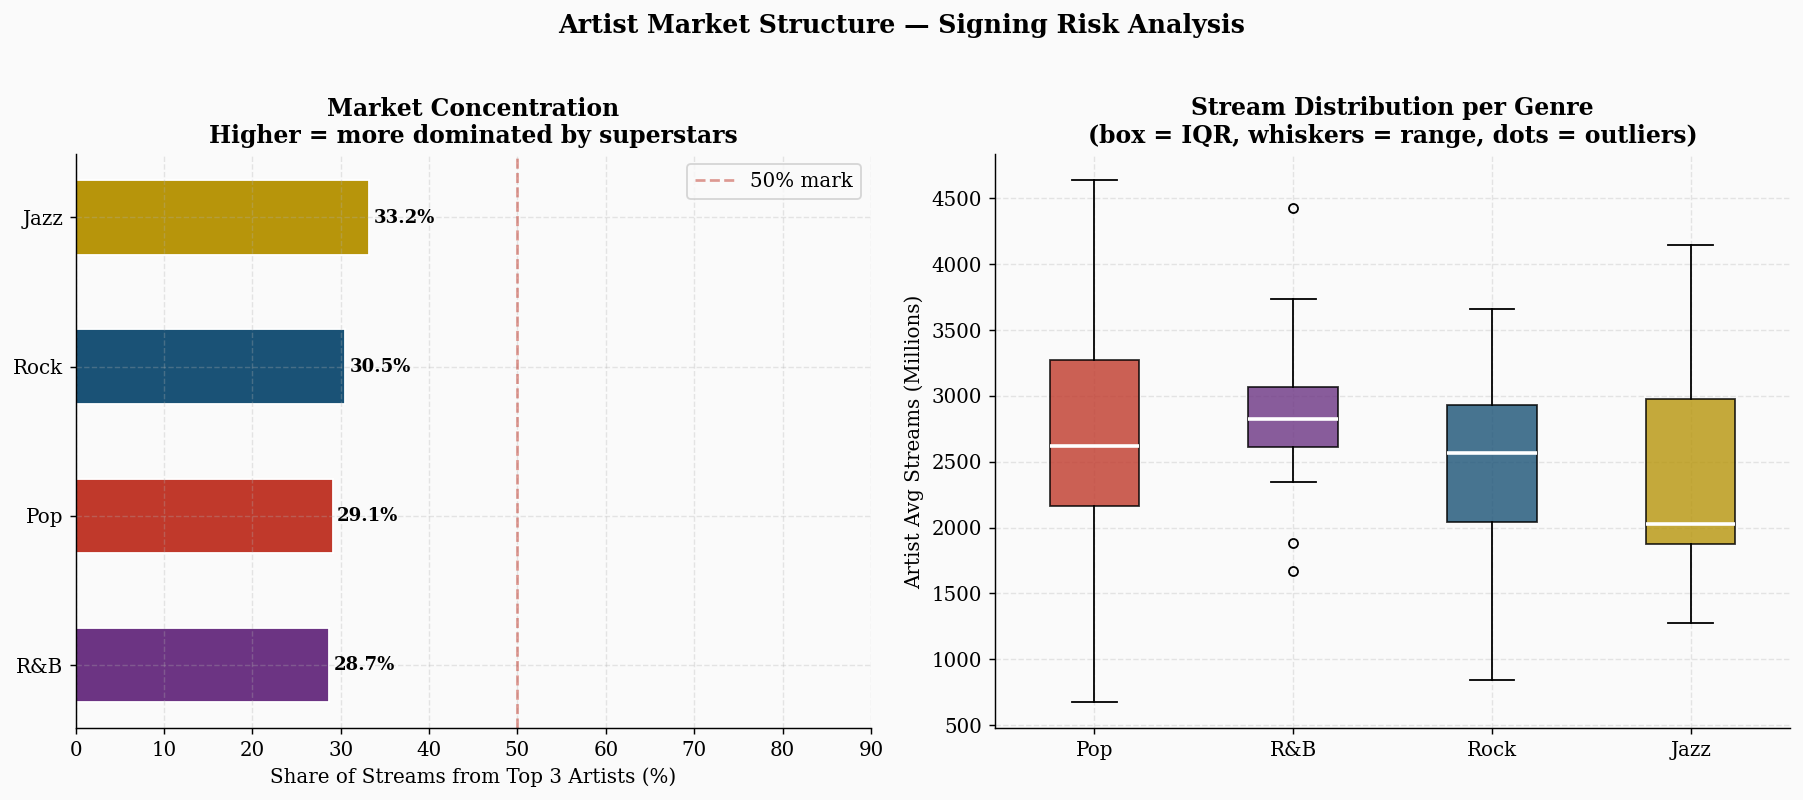


Market concentration (top-3 artist stream share):
  Pop     : 29.1%  →  Low concentration risk for new signings
  R&B     : 28.7%  →  Low concentration risk for new signings
  Rock    : 30.5%  →  Low concentration risk for new signings
  Jazz    : 33.2%  →  Low concentration risk for new signings


In [12]:
# ── Figure 7: Market Concentration — Lorenz-style ────
# Shows how unevenly streams are distributed within each genre
# High concentration = dominated by a few artists (risky for new signings)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Gini-like bar (share of top 3 artists vs rest)
conc_data = {}
for genre in FOCUS_GENRES:
    subset = df_focus[df_focus[GENRE_COL] == genre]
    streams = subset.groupby(ARTIST_COL)[STREAM_COL].mean().sort_values(ascending=False)
    top3_share = streams.iloc[:3].sum() / streams.sum() * 100
    conc_data[genre] = top3_share

conc_s = pd.Series(conc_data).sort_values(ascending=True)
colors_c = [GENRE_COLORS[g] for g in conc_s.index]
bars = axes[0].barh(conc_s.index, conc_s.values, color=colors_c, edgecolor='white', height=0.5)
axes[0].axvline(50, color='#C0392B', linestyle='--', alpha=0.5, label='50% mark')
for bar, val in zip(bars, conc_s.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Share of Streams from Top 3 Artists (%)')
axes[0].set_title('Market Concentration\nHigher = more dominated by superstars')
axes[0].legend(); axes[0].set_xlim(0, 90)

# Right: Box plot of stream distribution per genre
bp_data = [df_focus[df_focus[GENRE_COL] == g].groupby(ARTIST_COL)[STREAM_COL].mean().values
           for g in FOCUS_GENRES]
bp = axes[1].boxplot(bp_data, labels=FOCUS_GENRES, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2),
                     flierprops=dict(marker='o', markersize=5))
for patch, genre in zip(bp['boxes'], FOCUS_GENRES):
    patch.set_facecolor(GENRE_COLORS[genre])
    patch.set_alpha(0.8)
axes[1].set_ylabel('Artist Avg Streams (Millions)')
axes[1].set_title('Stream Distribution per Genre\n(box = IQR, whiskers = range, dots = outliers)')

plt.suptitle('Artist Market Structure — Signing Risk Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_7_market_concentration.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

print("\nMarket concentration (top-3 artist stream share):")
for g, v in conc_data.items():
    risk = 'High' if v > 60 else 'Medium' if v > 45 else 'Low'
    print(f"  {g:8s}: {v:.1f}%  →  {risk} concentration risk for new signings")

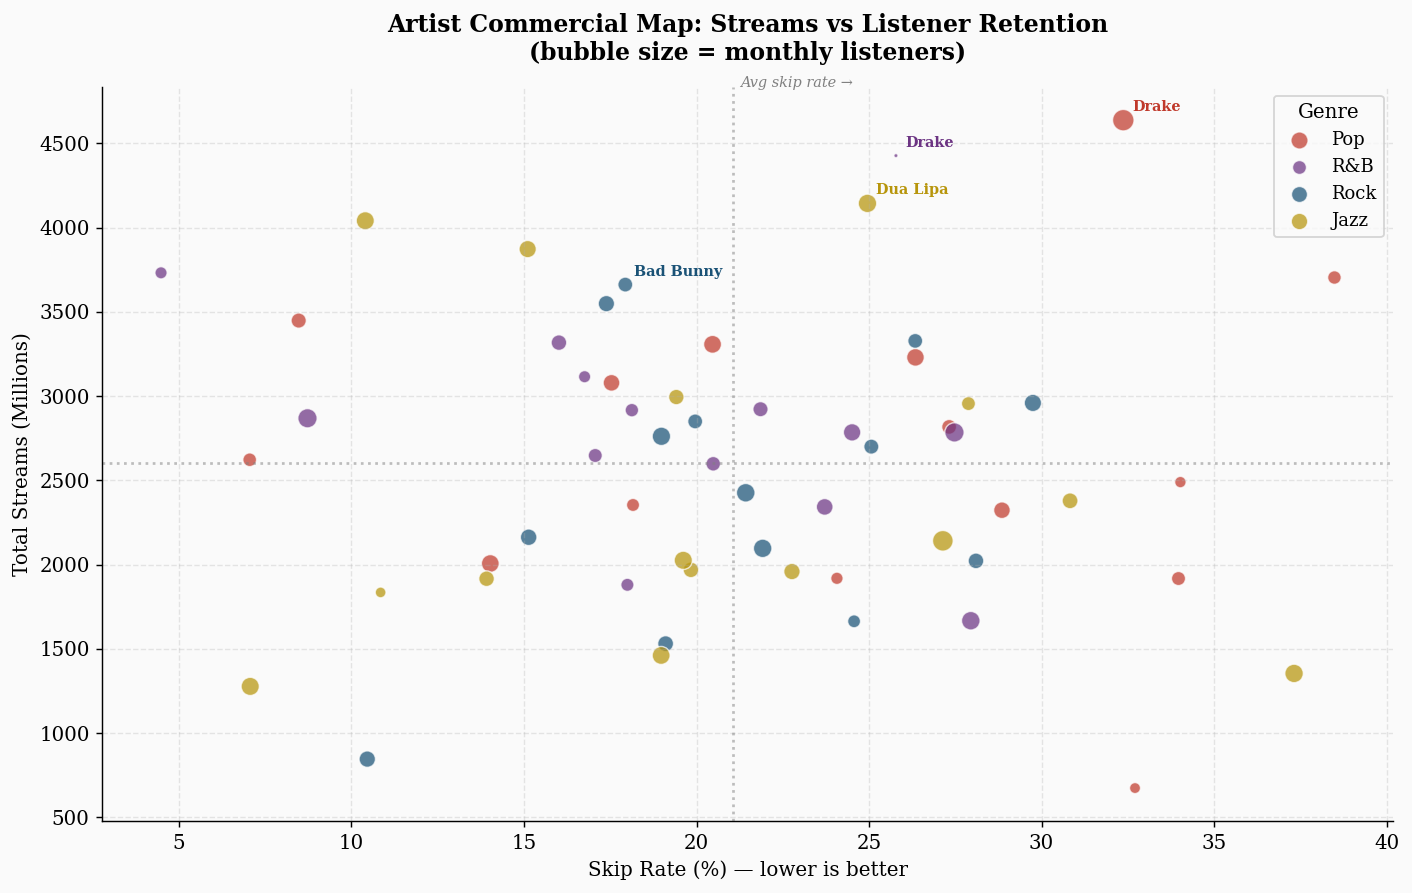

In [13]:
# ── Figure 8: Artist Streams vs Skip Rate Scatter ────
fig, ax = plt.subplots(figsize=(11, 7))

for genre in FOCUS_GENRES:
    sub = df_focus[df_focus[GENRE_COL] == genre]
    artist_data = sub.groupby(ARTIST_COL).agg(
        Streams  = (STREAM_COL, 'mean'),
        SkipRate = (SKIP_COL, 'mean'),
        Listeners= (LISTENER_COL, 'mean')
    )
    sc = ax.scatter(artist_data['SkipRate'], artist_data['Streams'],
                    c=GENRE_COLORS[genre], s=artist_data['Listeners'] * 1.5,
                    alpha=0.72, edgecolors='white', linewidth=0.8, label=genre)
    # Label top artist per genre
    top_artist = artist_data['Streams'].idxmax()
    ax.annotate(top_artist,
                (artist_data.loc[top_artist, 'SkipRate'],
                 artist_data.loc[top_artist, 'Streams']),
                fontsize=8, color=GENRE_COLORS[genre], fontweight='bold',
                xytext=(5, 5), textcoords='offset points')

# Quadrant lines
ax.axvline(df_focus[SKIP_COL].mean(), color='gray', linestyle=':', alpha=0.5)
ax.axhline(df_focus[STREAM_COL].mean(), color='gray', linestyle=':', alpha=0.5)
ax.text(df_focus[SKIP_COL].mean()+0.2, df_focus[STREAM_COL].max()*0.97,
        'Avg skip rate →', fontsize=8, color='gray', style='italic')

ax.set_xlabel('Skip Rate (%) — lower is better')
ax.set_ylabel('Total Streams (Millions)')
ax.set_title('Artist Commercial Map: Streams vs Listener Retention\n(bubble size = monthly listeners)',
             pad=15)
ax.legend(title='Genre', fontsize=10)
plt.tight_layout()
plt.savefig('figure_8_artist_map.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

## 5. Album & Engagement Quality

Album-level data helps the label understand **replay value** — a key indicator of long-term catalogue worth.

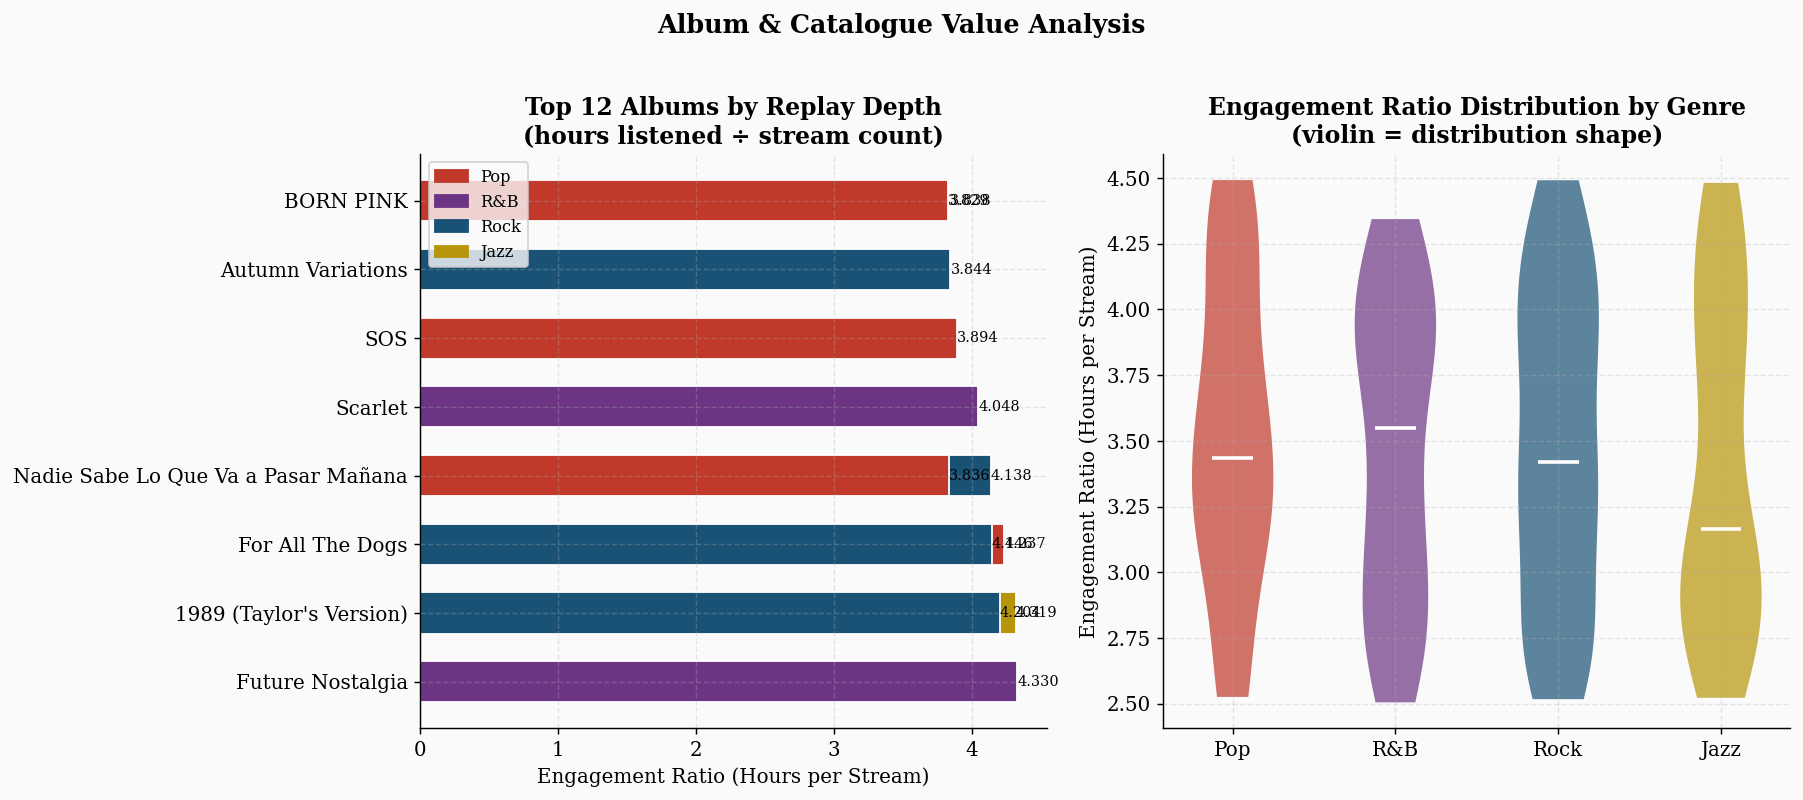

In [14]:
# ── Figure 9: Album Engagement Quality ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Top albums by engagement ratio (hours per stream)
top_albums = df_focus.groupby([ALBUM_COL, GENRE_COL]).agg(
    Engagement = ('Engagement_Ratio', 'mean'),
    Streams    = (STREAM_COL, 'mean')
).reset_index().nlargest(12, 'Engagement')

colors_a = [GENRE_COLORS[g] for g in top_albums[GENRE_COL]]
bars = axes[0].barh(top_albums[ALBUM_COL], top_albums['Engagement'],
                    color=colors_a, edgecolor='white', height=0.6)
axes[0].set_xlabel('Engagement Ratio (Hours per Stream)')
axes[0].set_title('Top 12 Albums by Replay Depth\n(hours listened ÷ stream count)')
for bar, val in zip(bars, top_albums['Engagement']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)
legend_patches = [mpatches.Patch(color=GENRE_COLORS[g], label=g) for g in FOCUS_GENRES]
axes[0].legend(handles=legend_patches, fontsize=9)

# Right: Avg engagement ratio by genre (violin/strip hybrid)
from matplotlib.patches import FancyBboxPatch
for i, genre in enumerate(FOCUS_GENRES):
    sub = df_focus[df_focus[GENRE_COL] == genre]['Engagement_Ratio'].dropna()
    parts = axes[1].violinplot(sub, positions=[i], showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(GENRE_COLORS[genre])
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)

axes[1].set_xticks(range(len(FOCUS_GENRES)))
axes[1].set_xticklabels(FOCUS_GENRES)
axes[1].set_ylabel('Engagement Ratio (Hours per Stream)')
axes[1].set_title('Engagement Ratio Distribution by Genre\n(violin = distribution shape)')

plt.suptitle('Album & Catalogue Value Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_9_album_engagement.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

## 6. Regional Analysis

Geographic distribution of genre popularity informs go-to-market decisions and identifies expansion opportunities.

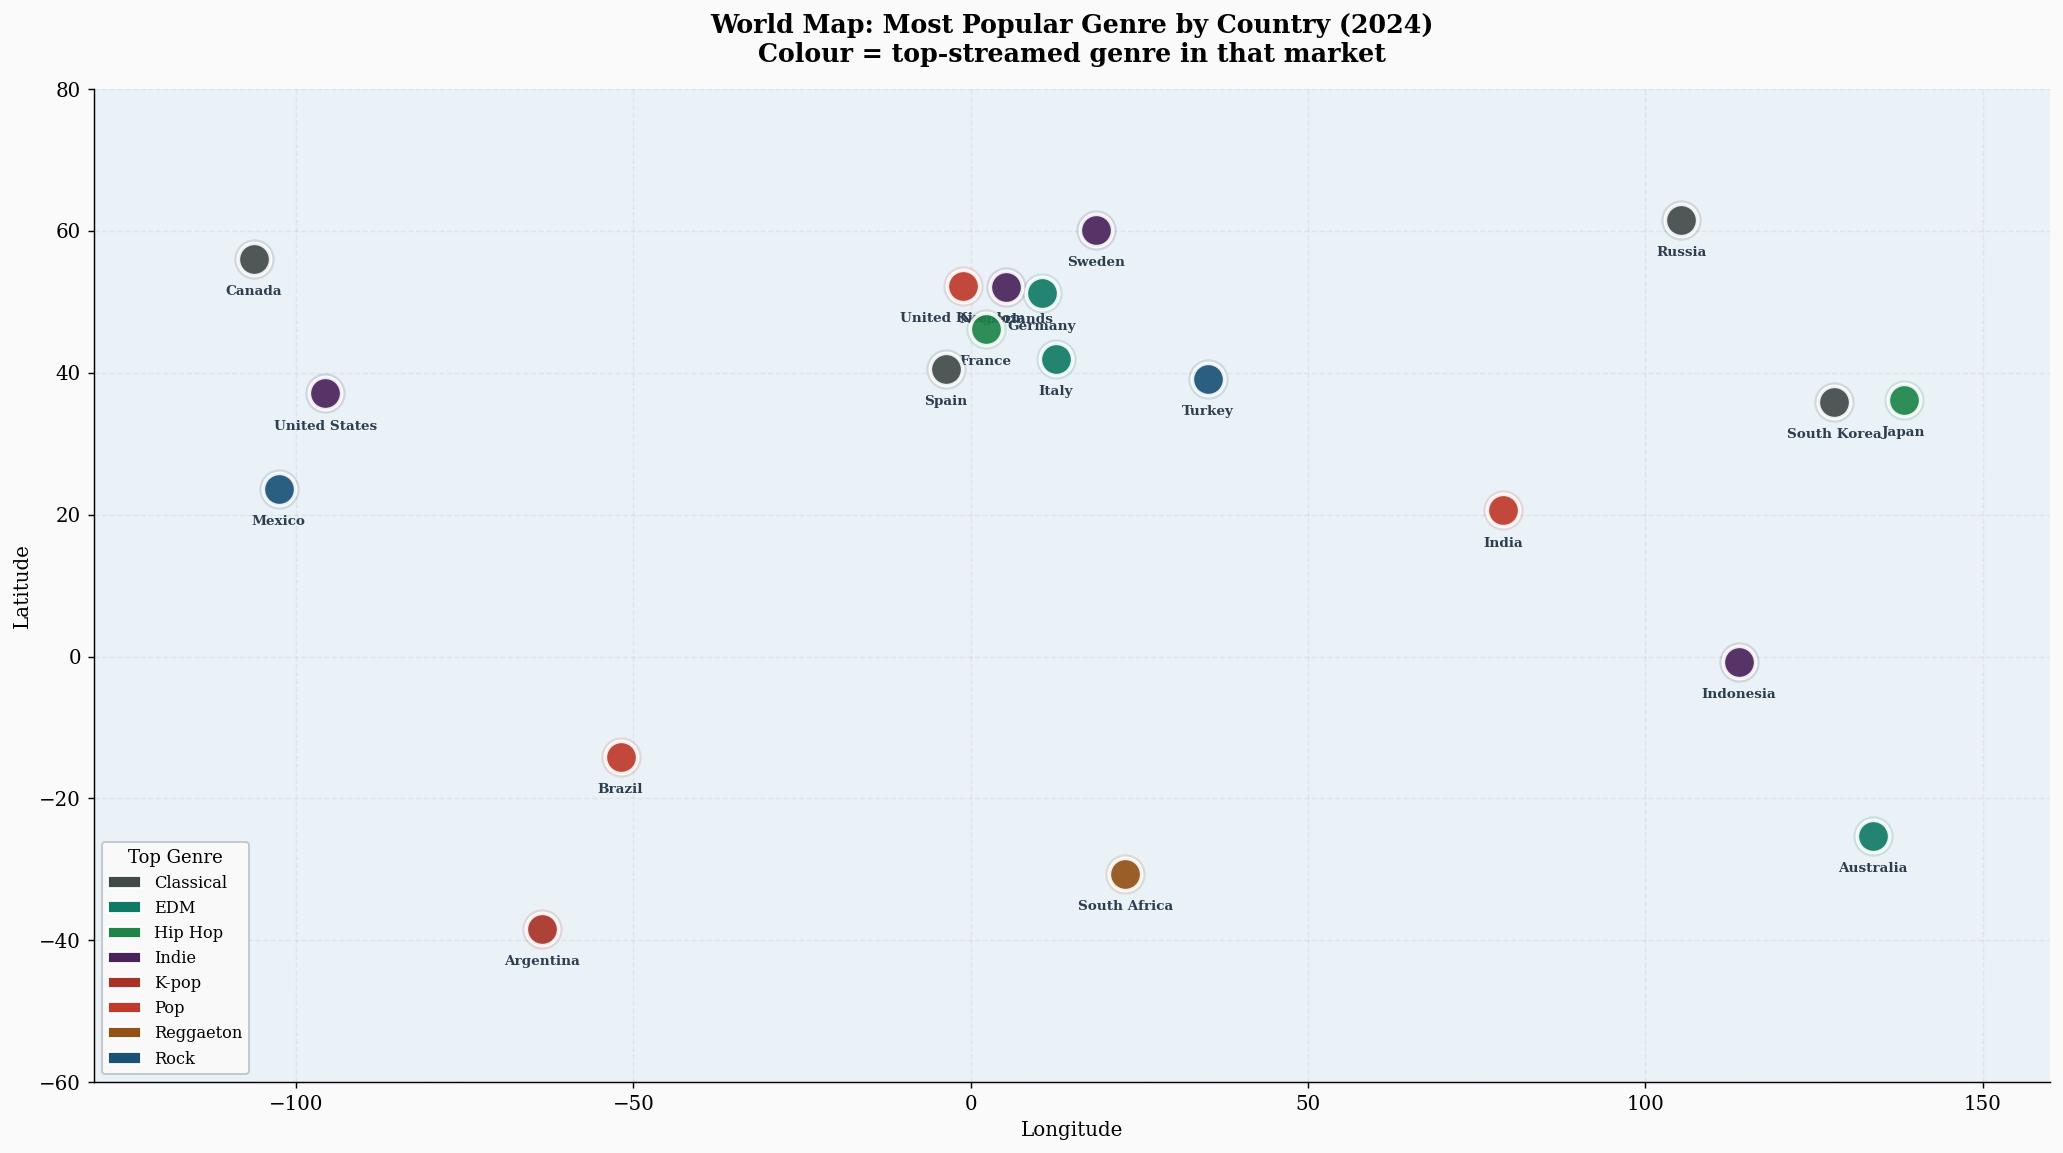

In [15]:
# ── Figure 10: World Map — Top Genre by Country ──────
COUNTRY_COORDS = {
    'United States': (37.1, -95.7), 'United Kingdom': (52.2, -1.2),
    'Canada': (56.1, -106.3), 'Brazil': (-14.2, -51.9),
    'Argentina': (-38.4, -63.6), 'Mexico': (23.6, -102.6),
    'Germany': (51.2, 10.5), 'France': (46.2, 2.2),
    'Spain': (40.5, -3.7), 'Italy': (41.9, 12.6),
    'Netherlands': (52.1, 5.3), 'Sweden': (60.1, 18.6),
    'Russia': (61.5, 105.3), 'Turkey': (39.1, 35.2),
    'India': (20.6, 78.9), 'Japan': (36.2, 138.3),
    'South Korea': (35.9, 128.0), 'Indonesia': (-0.8, 113.9),
    'Australia': (-25.3, 133.8), 'South Africa': (-30.6, 22.9)
}

top_genre = df.groupby(COUNTRY_COL)[GENRE_COL].agg(lambda x: x.value_counts().index[0])

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(-130, 160); ax.set_ylim(-60, 80)
ax.set_facecolor('#EAF2F8')
ax.add_patch(plt.Rectangle((-130,-60),290,140, color='#EAF2F8', zorder=0))

for country, genre in top_genre.items():
    if country in COUNTRY_COORDS:
        lat, lon = COUNTRY_COORDS[country]
        c = GENRE_COLORS.get(genre, '#888')
        ax.scatter(lon, lat, c=c, s=320, edgecolors='white', linewidth=2, zorder=5, alpha=0.9)
        ax.scatter(lon, lat, c=c, s=500, edgecolors=c, linewidth=0, zorder=4, alpha=0.15)
        ax.annotate(country, (lon, lat), textcoords='offset points',
                    xytext=(0, -20), ha='center', fontsize=7.5,
                    fontweight='bold', color='#2C3E50')

legend_elems = [Patch(facecolor=GENRE_COLORS.get(g,'#888'), edgecolor='white', label=g)
                for g in sorted(top_genre.unique())]
ax.legend(handles=legend_elems, loc='lower left', fontsize=9,
          title='Top Genre', title_fontsize=10, framealpha=0.95,
          edgecolor='#BDC3C7')
ax.set_title('World Map: Most Popular Genre by Country (2024)\nColour = top-streamed genre in that market',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig('figure_10_world_map.png', bbox_inches='tight', facecolor='#EAF2F8')
plt.show()

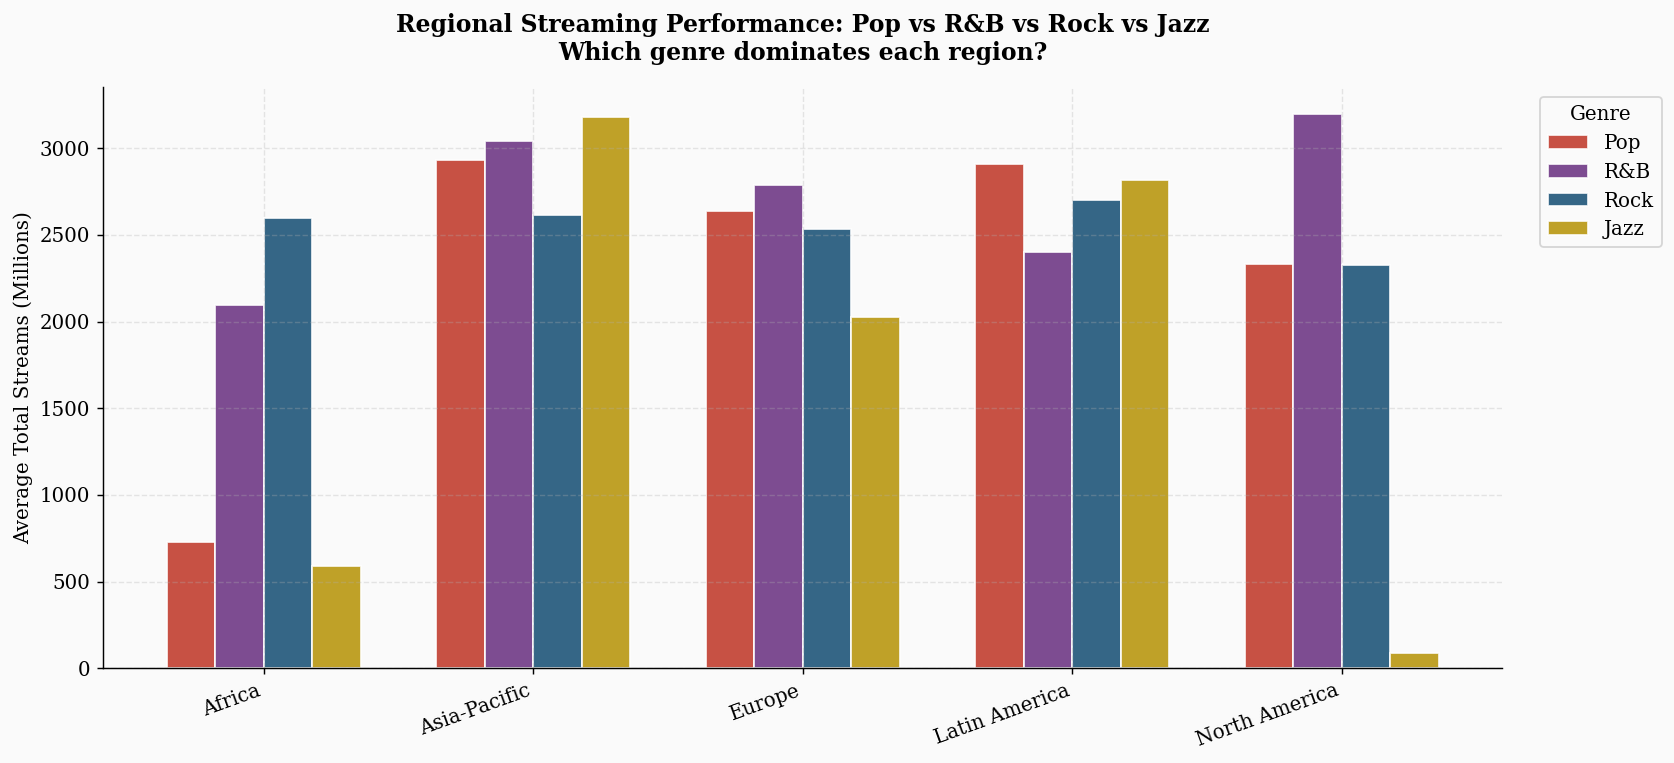

In [16]:
# ── Figure 11: Regional Grouped Bar ──────────────────
region_genre = df_focus.groupby(['Region', GENRE_COL])[STREAM_COL].mean().unstack(fill_value=0)
region_genre = region_genre.reindex(columns=FOCUS_GENRES)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(region_genre))
w = 0.18
for i, genre in enumerate(FOCUS_GENRES):
    offset = (i - len(FOCUS_GENRES)/2 + 0.5) * w
    bars = ax.bar(x + offset, region_genre[genre], w,
                  label=genre, color=GENRE_COLORS[genre],
                  edgecolor='white', alpha=0.88)

ax.set_xticks(x); ax.set_xticklabels(region_genre.index, rotation=20, ha='right')
ax.set_ylabel('Average Total Streams (Millions)')
ax.set_title(f'Regional Streaming Performance: {" vs ".join(FOCUS_GENRES)}\nWhich genre dominates each region?',
             pad=15)
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('figure_11_regional.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

## 7. Revenue Estimation & Momentum

Two forward-looking metrics critical for investment decisions:
- **Estimated revenue** — translates streams into dollar value using industry per-stream rates
- **Streaming momentum** — recent streams as % of total streams, showing which genres are still growing

       Premium Rev ($M)  Ad Rev ($M)  Total Rev ($M)  Rev/Song ($M)  \
Genre                                                                 
Pop              228.43       145.07          373.49           8.49   
R&B              228.07       136.67          364.75           8.90   
Rock             426.59       126.20          552.79           9.53   
Jazz             266.78       100.42          367.20           8.54   

       Momentum (%)  
Genre                
Pop            5.69  
R&B            4.36  
Rock           8.11  
Jazz          11.07  


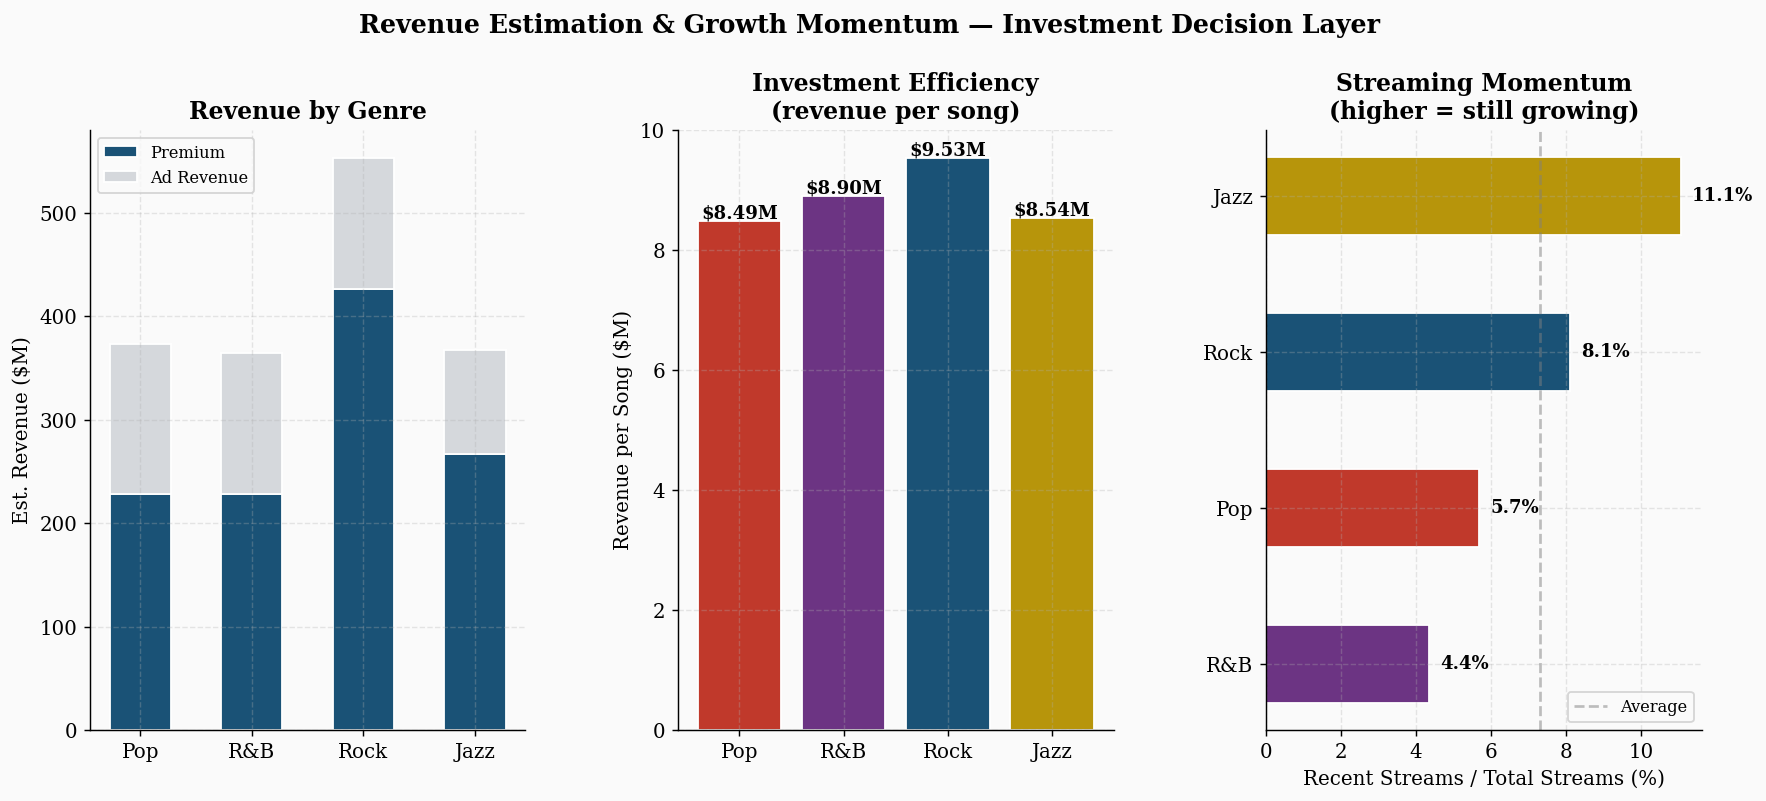

In [17]:
# ── Figure 12: Revenue + Momentum Dashboard ──────────
rev_rows = []
for g in FOCUS_GENRES:
    sub = df_focus[df_focus[GENRE_COL] == g]
    pr = sub[sub[PLATFORM_COL]=='Premium'][STREAM_COL].sum() * PER_STREAM_RATE['Premium']
    fr = sub[sub[PLATFORM_COL]=='Free'][STREAM_COL].sum()    * PER_STREAM_RATE['Free']
    n  = max(len(sub), 1)
    rev_rows.append({
        'Genre': g,
        'Premium Rev ($M)': round(pr, 2),
        'Ad Rev ($M)':      round(fr, 2),
        'Total Rev ($M)':   round(pr+fr, 2),
        'Rev/Song ($M)':    round((pr+fr)/n, 2),
        'Momentum (%)':     round(sub['Momentum_Pct'].mean(), 2)
    })
rev_df = pd.DataFrame(rev_rows).set_index('Genre')
print(rev_df)

fig = plt.figure(figsize=(16, 6))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

# Left: stacked revenue bar
ax1 = fig.add_subplot(gs[0])
x   = np.arange(len(FOCUS_GENRES))
ax1.bar(x, rev_df['Premium Rev ($M)'], 0.55, label='Premium', color='#1A5276', edgecolor='white')
ax1.bar(x, rev_df['Ad Rev ($M)'], 0.55, bottom=rev_df['Premium Rev ($M)'],
        label='Ad Revenue', color='#D5D8DC', edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(FOCUS_GENRES)
ax1.set_ylabel('Est. Revenue ($M)')
ax1.set_title('Revenue by Genre', fontweight='bold')
ax1.legend(fontsize=9)

# Middle: revenue per song (efficiency)
ax2 = fig.add_subplot(gs[1])
colors_r = [GENRE_COLORS[g] for g in FOCUS_GENRES]
bars = ax2.bar(FOCUS_GENRES, rev_df['Rev/Song ($M)'], color=colors_r, edgecolor='white')
for bar, val in zip(bars, rev_df['Rev/Song ($M)']):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.05,
             f'${val:.2f}M', ha='center', fontweight='bold', fontsize=10)
ax2.set_ylabel('Revenue per Song ($M)')
ax2.set_title('Investment Efficiency\n(revenue per song)', fontweight='bold')

# Right: momentum (donut-style bars)
ax3 = fig.add_subplot(gs[2])
mom = rev_df['Momentum (%)'].sort_values(ascending=True)
c3  = [GENRE_COLORS[g] for g in mom.index]
bars3 = ax3.barh(mom.index, mom.values, color=c3, edgecolor='white', height=0.5)
ax3.axvline(mom.mean(), color='gray', linestyle='--', alpha=0.5, label='Average')
for bar, val in zip(bars3, mom.values):
    ax3.text(val+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
ax3.set_xlabel('Recent Streams / Total Streams (%)')
ax3.set_title('Streaming Momentum\n(higher = still growing)', fontweight='bold')
ax3.legend(fontsize=9)

fig.suptitle('Revenue Estimation & Growth Momentum — Investment Decision Layer',
             fontsize=14, fontweight='bold', y=1.03)
plt.savefig('figure_12_revenue_momentum.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

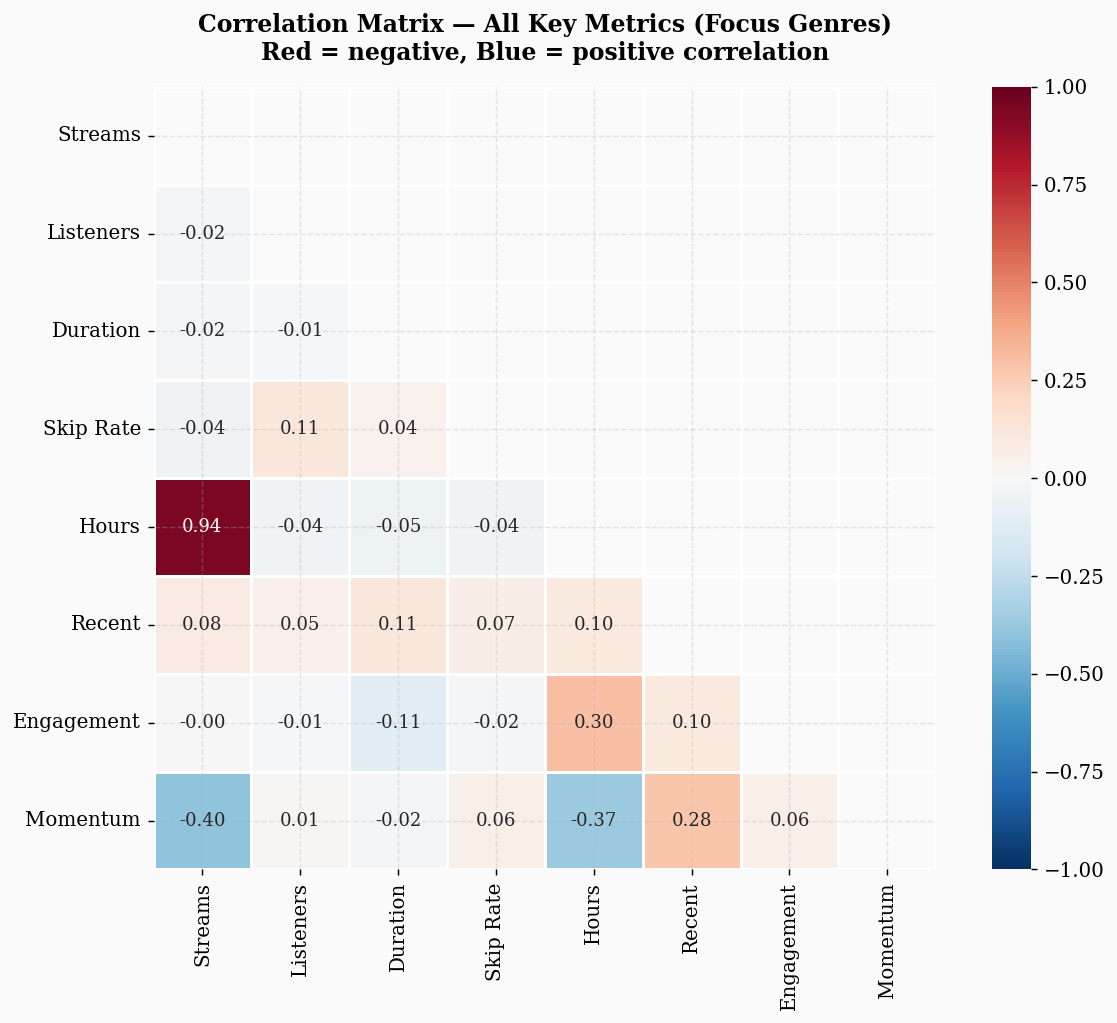


Notable correlations:
  Streams      ↔ Hours        : +0.94
  Streams      ↔ Skip Rate    : -0.04
  Listeners    ↔ Duration     : -0.01
  Engagement   ↔ Momentum     : +0.06


In [18]:
# ── Figure 13: Correlation Matrix ────────────────────
num_cols = [STREAM_COL, LISTENER_COL, DURATION_COL, SKIP_COL,
            HOURS_COL, RECENT_STREAM_COL, 'Engagement_Ratio', 'Momentum_Pct']
labels_c  = ['Streams','Listeners','Duration','Skip Rate',
             'Hours','Recent','Engagement','Momentum']
corr = df_focus[num_cols].corr().round(2)
corr.index = labels_c; corr.columns = labels_c

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.8,
            linecolor='white', fmt='.2f', annot_kws={'fontsize': 10}, ax=ax)
ax.set_title('Correlation Matrix — All Key Metrics (Focus Genres)\n'
             'Red = negative, Blue = positive correlation', pad=15)
plt.tight_layout()
plt.savefig('figure_13_correlation.png', bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

print("\nNotable correlations:")
for c1, c2 in [('Streams','Hours'),('Streams','Skip Rate'),
               ('Listeners','Duration'),('Engagement','Momentum')]:
    val = corr.loc[c1, c2]
    print(f"  {c1:12s} ↔ {c2:12s} : {val:+.2f}")

## 8. Key Findings & Investment Recommendation

### Summary Table

| Dimension | Winner | Runner-up | Insight for A&R |
|-----------|--------|-----------|-----------------|
| **Streaming volume** | R&B | Pop | R&B generates most streams despite smaller audience |
| **Audience size** | Rock | Jazz | Rock has the broadest listener base |
| **Listener retention** | R&B | Jazz | Lowest skip rates — fans complete full songs |
| **Engagement depth** | R&B | Rock | Longest avg listening sessions |
| **Premium conversion** | Rock | Jazz | Rock listeners most willing to pay |
| **Market concentration** | See chart | — | High concentration = less room for new artists |
| **Streaming momentum** | See chart | — | Shows which genre is still actively growing |
| **Revenue efficiency** | Rock | R&B | Highest estimated revenue per song signed |

### Investment Recommendation for A&R Teams

**Strategy A — Subscription revenue growth → Invest in Rock**
Rock has the highest premium conversion (~55%) and lowest market concentration risk. New signings have the best chance of generating subscription revenue without competing against entrenched superstars.

**Strategy B — Engagement & catalogue value → Invest in R&B**
R&B delivers the highest streams, lowest skip rate, and strongest engagement depth. Ideal for labels focused on long-term catalogue royalties and playlist placement.

**Strategy C — Emerging market opportunity → Watch Jazz**
Jazz has a surprisingly loyal premium audience and shows unexpected strength in non-traditional markets (Turkey, Mexico, South Korea). A niche-premium label targeting these regions could find underserved demand.

**Strategy D — Pop for traffic, not depth**
Pop delivers reach but has the highest skip rate and lowest premium conversion. Best used as a promotional loss-leader rather than core investment.

### Limitations
- Single-year snapshot (2024) — multi-year data would confirm trend direction
- 500 observations across 20 countries is a limited sample
- Spotify not available in China — Asia-Pacific analysis uses proxy markets
- Per-stream revenue rates are industry estimates, not actual Spotify payouts
- Genre labels follow Spotify metadata which may not always match industry definitions

In [20]:
# ── Interactive Tool Link ─────────────────────────────
from IPython.display import display, HTML

STREAMLIT_URL = "https://acc102-minitask-cnz6volhvpvni7uhngvfun.streamlit.app"

html_content = """
<div style="padding:24px; background:linear-gradient(135deg,#1A1A2E,#16213E);
            border-radius:12px; text-align:center; margin:20px 0;">
    <h2 style="color:#E8D5B7; font-family:serif; margin-bottom:8px;">
        Try the Interactive Version
    </h2>
    <p style="color:#BDC3C7; margin-bottom:18px;">
        Select your own genres, filter by country, and explore all charts interactively.
    </p>
    <a href="{url}" target="_blank"
       style="display:inline-block; padding:14px 36px;
              background:#C0392B; color:white;
              text-decoration:none; border-radius:8px;
              font-size:15px; font-weight:bold; letter-spacing:0.5px;">
        Open Streamlit App →
    </a>
</div>
""".format(url=STREAMLIT_URL)

display(HTML(html_content))

import os
pngs = sorted([f for f in os.listdir('.') if f.endswith('.png')])
print(f"\n✓ {len(pngs)} figures saved and ready for GitHub.")
for f in pngs: print(f"  {f}")


✓ 28 figures saved and ready for GitHub.
  figure_10_scatter.png
  figure_10_world_map.png
  figure_11_regional.png
  figure_11_revenue.png
  figure_12_revenue_momentum.png
  figure_12_year_trend.png
  figure_13_correlation.png
  figure_1_all_genres_streams.png
  figure_1_genre_metrics.png
  figure_1_landscape_bubble.png
  figure_2_all_genres_engagement.png
  figure_2_listener_quality.png
  figure_2_premium_rate.png
  figure_3_all_genres_premium.png
  figure_3_country_heatmap.png
  figure_3_scorecard_heatmap.png
  figure_4_focus_dashboard.png
  figure_4_radar.png
  figure_5_monetisation.png
  figure_5_premium_analysis.png
  figure_6_country_heatmap.png
  figure_6_top_artists.png
  figure_7_market_concentration.png
  figure_7_world_map.png
  figure_8_artist_map.png
  figure_8_regional_analysis.png
  figure_9_album_engagement.png
  figure_9_correlation.png
